In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Reload modules to pick up changes
import importlib
import sys

# Remove cached modules
for module in list(sys.modules.keys()):
    if 'InterventionalPFN' in module or 'SimplePFN' in module:
        del sys.modules[module]

# Now import fresh
from InterventionalPFN_sklearn import InterventionalPFNSklearn
from SimplePFN_sklearn import SimplePFNSklearn
from sklearn.ensemble import RandomForestRegressor
from src.priordata_processing.BasicProcessing import BasicProcessing
import torch
from src.priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist


In [3]:
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16661593.0/step_30000_93.pt"

intpfn = InterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    verbose=True,  # Enable verbose mode to see what's being loaded
    max_n_train = None,
)

# Now the config should load properly with the fixed load() method
intpfn.load()

config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic_predictive.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16661592.0/step_30000_92.pt"

print("Loading observational PFN...")
obspfn = InterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    verbose=True,  # Enable verbose mode to see diagnostic messages
    max_n_train = None,
)
obspfn.load()


# Processor should match the config: 50 features (excluding target, including intervention column)
processor = BasicProcessing(
    n_features=50,
    max_n_features=50,
    n_train_samples = 500,
    max_n_train_samples=500,
    n_test_samples=500,
    max_n_test_samples=500,
    dropout_prob=0.0,
    target_feature=2,
    intervened_feature=0,
    feature_standardize= True,
    shuffle_features=False,
    shuffle_samples=False,
    feature_negative_one_one_scaling=  False,
    target_negative_one_one_scaling= True,
    remove_outliers= True,
    outlier_quantile= 0.99,
    yeo_johnson= False
)



[InterventionalPFNSklearn] Loading with config_path: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml
[InterventionalPFNSklearn] verbose=True
[InterventionalPFNSklearn] Config loaded. Top-level keys: ['experiment_name', 'description', 'mode', 'scm_config', 'dataset_config', 'preprocessing_config', 'model_config', 'training_config']
[InterventionalPFNSklearn] Loaded model_kwargs from config: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.0, 'output_dim': 1, 'hidden_mult': 2, 'normalize_features': True, 'use_same_row_mlp': True, 'n_sample_attention_sink_rows': 10, 'n_feature_attention_sink_cols': 0}
[InterventionalPFNSklearn] BarDistribution enabled with 1000 bars
[InterventionalPFNSklearn] Model output_dim set to 1004
[InterventionalPFNSklearn] Building InterventionalPFN with kwargs: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.0, 'output_dim': 

### Three variables, no hidden confounder

In [4]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_dataset(data_dict, title="Dataset Visualization", figsize=None):
    """
    Visualize a dataset with pairwise scatterplots and histograms on the diagonal.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary where keys are variable names (e.g., 0, 1, 2) and values are tensors
    title : str
        Title for the plot
    figsize : tuple, optional
        Figure size (width, height). If None, automatically determined based on number of variables
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    """
    # Convert tensors to numpy and create DataFrame
    df_data = {}
    for key, value in data_dict.items():
        if hasattr(value, 'numpy'):
            df_data[f'X{key}'] = value.numpy().flatten()
        else:
            df_data[f'X{key}'] = value.flatten()
    
    df = pd.DataFrame(df_data)
    
    # Determine figure size based on number of variables
    n_vars = len(df.columns)
    if figsize is None:
        figsize = (3 * n_vars, 3 * n_vars)
    
    # Create pair plot
    fig, axes = plt.subplots(n_vars, n_vars, figsize=figsize)
    
    # If only one variable, ensure axes is 2D array
    if n_vars == 1:
        axes = np.array([[axes]])
    
    # Plot each pair
    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: histogram
                ax.hist(df.iloc[:, i], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
                ax.set_ylabel('Frequency')
            else:
                # Off-diagonal: scatterplot
                ax.scatter(df.iloc[:, j], df.iloc[:, i], alpha=0.5, s=10)
            
            # Labels
            if i == n_vars - 1:
                ax.set_xlabel(df.columns[j])
            else:
                ax.set_xticklabels([])
            
            if j == 0:
                if i != j:  # Only set ylabel for off-diagonal plots
                    ax.set_ylabel(df.columns[i])
            else:
                ax.set_yticklabels([])
            
            # Grid
            ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout()
    
    return fig

# Example usage:
# visualize_dataset(obs1, title="Observational Data (obs1)")
# visualize_dataset(interv1, title="Interventional Data (interv1)")

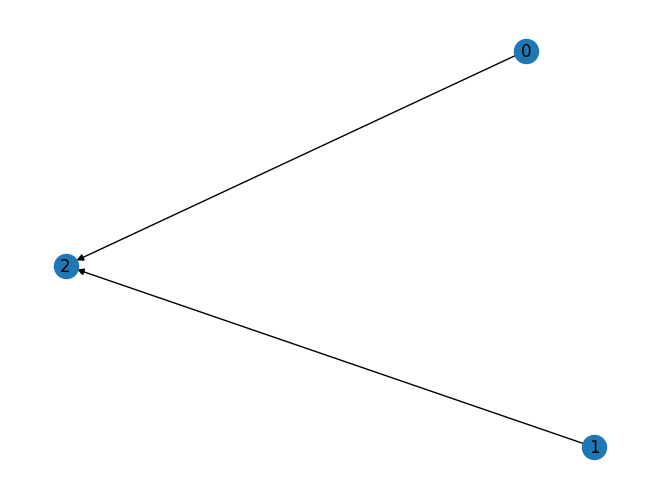

SUMMARY - TRAIN SET (obs0 - used for training)
Method               Train MSE       Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.019463        0.006399        0.077838        N/A            
Obs PFN              0.088535        0.016052        0.017795        0.122553       
Int PFN              0.097686        0.016222        0.013616        0.192447       

SUMMARY - OBS2 SET (obs1 - second observational, not trained on)
Method               Obs2 MSE        Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.124701        0.153283        0.061453        N/A            
Obs PFN              0.099703        0.148399        0.016833        0.378368       
Int PFN              0.104945        0.143001     

In [6]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             #(1, 0), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

number_train_samples = 500
number_test_samples = 500
            
# sample the observational data first
scm.sample_exogenous(num_samples=number_train_samples)
scm.sample_endogenous(num_samples=number_train_samples)

obs0_raw = scm.propagate(num_samples=number_train_samples)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}

# now, do interventional sampling
# for interventional sampling, first determine intervention node
intervention_node = 0

scm.sample_exogenous(num_samples=number_test_samples) #sample observational data again. 
scm.sample_endogenous(num_samples=number_test_samples) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=number_test_samples)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)

scm.intervene(node = 0) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist

# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=number_test_samples)
scm.sample_endogenous(num_samples=number_test_samples)

interv1_raw = scm.propagate(num_samples=number_test_samples)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

# Also process the second observational dataset (obs1)
obs1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs1_raw.items()}

X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
X_obs2, T_obs2, Y_obs2, _, _, _ = processor.process_from_splits(obs1, interv1)  # Process second obs dataset

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1)
XT_obs2 = torch.cat([X_obs2, T_obs2], dim=1)

# ============= RANDOM FOREST =============
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and metrics
rf_preds_train = rf.predict(XT_train.numpy())
rf_mse_train = np.mean((Y_train.numpy().ravel() - rf_preds_train)**2)
rf_bias_train = np.mean(rf_preds_train) - np.mean(Y_train.numpy().ravel())
rf_variance_train = np.var(rf_preds_train)

# Test predictions and metrics
rf_preds_test = rf.predict(XT_test.numpy())
rf_mse_test = np.mean((Y_test.numpy().ravel() - rf_preds_test)**2)
rf_bias_test = np.mean(rf_preds_test) - np.mean(Y_test.numpy().ravel())
rf_variance_test = np.var(rf_preds_test)

# Second obs predictions and metrics
rf_preds_obs2 = rf.predict(XT_obs2.numpy())
rf_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - rf_preds_obs2)**2)
rf_bias_obs2 = np.mean(rf_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
rf_variance_obs2 = np.var(rf_preds_obs2)

# ============= OBSERVATIONAL PFN =============
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)
X_obs2_ext = torch.cat([X_obs2, torch.zeros_like(T_obs2)], dim=1)

# Train predictions and metrics
obspfn_preds_train = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = np.mean((Y_train.numpy().ravel() - obspfn_preds_train)**2)
obspfn_bias_train = np.mean(obspfn_preds_train) - np.mean(Y_train.numpy().ravel())
obspfn_variance_train = np.var(obspfn_preds_train)

# Test predictions and metrics
obspfn_preds_test = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
obspfn_mse_test = np.mean((Y_test.numpy().ravel() - obspfn_preds_test)**2)
obspfn_bias_test = np.mean(obspfn_preds_test) - np.mean(Y_test.numpy().ravel())
obspfn_variance_test = np.var(obspfn_preds_test)

# Second obs predictions and metrics
obspfn_preds_obs2 = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
obspfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - obspfn_preds_obs2)**2)
obspfn_bias_obs2 = np.mean(obspfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
obspfn_variance_obs2 = np.var(obspfn_preds_obs2)

# Log-likelihood for train set
obspfn_log_lik_train = obspfn.predict_log_likelihood(
     X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv = Y_train.numpy()
)
obspfn_nll_train = -np.mean(obspfn_log_lik_train)

# Log-likelihood for test set
obspfn_log_lik_test = obspfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
obspfn_nll_test = -np.mean(obspfn_log_lik_test)

# Log-likelihood for second obs set
obspfn_log_lik_obs2 = obspfn.predict_log_likelihood(
    X_obs = X_obs2.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
obspfn_nll_obs2 = -np.mean(obspfn_log_lik_obs2)

# ============= INTERVENTIONAL PFN =============


# Train predictions and metrics
intpfn_preds_train = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"

)
intpfn_mse_train = np.mean((Y_train.numpy().ravel() - intpfn_preds_train)**2)
intpfn_bias_train = np.mean(intpfn_preds_train) - np.mean(Y_train.numpy().ravel())
intpfn_variance_train = np.var(intpfn_preds_train)

# Test predictions and metrics
intpfn_preds_test = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse_test = np.mean((Y_test.numpy().ravel() - intpfn_preds_test)**2)
intpfn_bias_test = np.mean(intpfn_preds_test) - np.mean(Y_test.numpy().ravel())
intpfn_variance_test = np.var(intpfn_preds_test)

# Second obs predictions and metrics
intpfn_preds_obs2 = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
intpfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - intpfn_preds_obs2)**2)
intpfn_bias_obs2 = np.mean(intpfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
intpfn_variance_obs2 = np.var(intpfn_preds_obs2)

# Log-likelihood for train set
intpfn_log_lik_train = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv=  Y_train.numpy()
)
intpfn_nll_train = -np.mean(intpfn_log_lik_train)

# Log-likelihood for test set
intpfn_log_lik_test = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
intpfn_nll_test = -np.mean(intpfn_log_lik_test)

# Log-likelihood for second obs set
intpfn_log_lik_obs2 = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
intpfn_nll_obs2 = -np.mean(intpfn_log_lik_obs2)

# ============= SUMMARY =============
print("="*120)
print("SUMMARY - TRAIN SET (obs0 - used for training)")
print("="*120)
print(f"{'Method':<20} {'Train MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_train:<15.6f} {rf_bias_train:<15.6f} {rf_variance_train:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_train:<15.6f} {obspfn_bias_train:<15.6f} {obspfn_variance_train:<15.6f} {obspfn_nll_train:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train:<15.6f} {intpfn_bias_train:<15.6f} {intpfn_variance_train:<15.6f} {intpfn_nll_train:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - OBS2 SET (obs1 - second observational, not trained on)")
print("="*120)
print(f"{'Method':<20} {'Obs2 MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_obs2:<15.6f} {rf_bias_obs2:<15.6f} {rf_variance_obs2:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_obs2:<15.6f} {obspfn_bias_obs2:<15.6f} {obspfn_variance_obs2:<15.6f} {obspfn_nll_obs2:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_obs2:<15.6f} {intpfn_bias_obs2:<15.6f} {intpfn_variance_obs2:<15.6f} {intpfn_nll_obs2:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - TEST SET (interventional)")
print("="*120)
print(f"{'Method':<20} {'Test MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_test:<15.6f} {rf_bias_test:<15.6f} {rf_variance_test:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_test:<15.6f} {obspfn_bias_test:<15.6f} {obspfn_variance_test:<15.6f} {obspfn_nll_test:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_test:<15.6f} {intpfn_bias_test:<15.6f} {intpfn_variance_test:<15.6f} {intpfn_nll_test:<15.6f}")
print("="*120)


# Simpe observational prediction

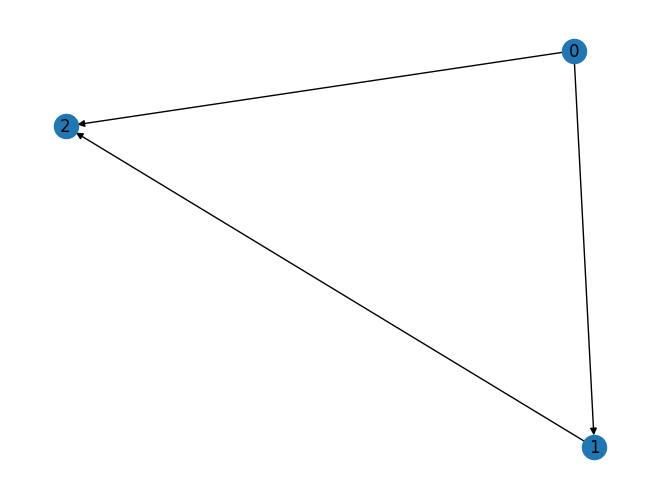

SUMMARY - TRAIN SET (obs0 - used for training)
Method               Train MSE       Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.014908        0.000153        0.066316        N/A            
Obs PFN              0.070641        0.019586        0.027373        0.028415       
Int PFN              0.070653        0.016754        0.024820        0.034684       

SUMMARY - OBS2 SET (obs1 - second observational, not trained on)
Method               Obs2 MSE        Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.087124        0.033515        0.052343        N/A            
Obs PFN              0.082697        0.046644        0.029366        0.330817       
Int PFN              0.082987        0.044587     

In [7]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)


# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

number_train_samples = 500
number_test_samples = 500
            
# sample the observational data first
scm.sample_exogenous(num_samples=number_train_samples)
scm.sample_endogenous(num_samples=number_train_samples)

obs0_raw = scm.propagate(num_samples=number_train_samples)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}

# now, do interventional sampling
# for interventional sampling, first determine intervention node
intervention_node = 0

scm.sample_exogenous(num_samples=number_test_samples) #sample observational data again. 
scm.sample_endogenous(num_samples=number_test_samples) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=number_test_samples)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)

scm.intervene(node = 0) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist

# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=number_test_samples)
scm.sample_endogenous(num_samples=number_test_samples)

interv1_raw = scm.propagate(num_samples=number_test_samples)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

# Also process the second observational dataset (obs1)
obs1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs1_raw.items()}

X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
X_obs2, T_obs2, Y_obs2, _, _, _ = processor.process_from_splits(obs1, interv1)  # Process second obs dataset

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1)
XT_obs2 = torch.cat([X_obs2, T_obs2], dim=1)

# ============= RANDOM FOREST =============
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and metrics
rf_preds_train = rf.predict(XT_train.numpy())
rf_mse_train = np.mean((Y_train.numpy().ravel() - rf_preds_train)**2)
rf_bias_train = np.mean(rf_preds_train) - np.mean(Y_train.numpy().ravel())
rf_variance_train = np.var(rf_preds_train)

# Test predictions and metrics
rf_preds_test = rf.predict(XT_test.numpy())
rf_mse_test = np.mean((Y_test.numpy().ravel() - rf_preds_test)**2)
rf_bias_test = np.mean(rf_preds_test) - np.mean(Y_test.numpy().ravel())
rf_variance_test = np.var(rf_preds_test)

# Second obs predictions and metrics
rf_preds_obs2 = rf.predict(XT_obs2.numpy())
rf_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - rf_preds_obs2)**2)
rf_bias_obs2 = np.mean(rf_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
rf_variance_obs2 = np.var(rf_preds_obs2)

# ============= OBSERVATIONAL PFN =============
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)
X_obs2_ext = torch.cat([X_obs2, torch.zeros_like(T_obs2)], dim=1)

# Train predictions and metrics
obspfn_preds_train = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = np.mean((Y_train.numpy().ravel() - obspfn_preds_train)**2)
obspfn_bias_train = np.mean(obspfn_preds_train) - np.mean(Y_train.numpy().ravel())
obspfn_variance_train = np.var(obspfn_preds_train)

# Test predictions and metrics
obspfn_preds_test = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
obspfn_mse_test = np.mean((Y_test.numpy().ravel() - obspfn_preds_test)**2)
obspfn_bias_test = np.mean(obspfn_preds_test) - np.mean(Y_test.numpy().ravel())
obspfn_variance_test = np.var(obspfn_preds_test)

# Second obs predictions and metrics
obspfn_preds_obs2 = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
obspfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - obspfn_preds_obs2)**2)
obspfn_bias_obs2 = np.mean(obspfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
obspfn_variance_obs2 = np.var(obspfn_preds_obs2)

# Log-likelihood for train set
obspfn_log_lik_train = obspfn.predict_log_likelihood(
     X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv = Y_train.numpy()
)
obspfn_nll_train = -np.mean(obspfn_log_lik_train)

# Log-likelihood for test set
obspfn_log_lik_test = obspfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
obspfn_nll_test = -np.mean(obspfn_log_lik_test)

# Log-likelihood for second obs set
obspfn_log_lik_obs2 = obspfn.predict_log_likelihood(
    X_obs = X_obs2.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
obspfn_nll_obs2 = -np.mean(obspfn_log_lik_obs2)

# ============= INTERVENTIONAL PFN =============


# Train predictions and metrics
intpfn_preds_train = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"

)
intpfn_mse_train = np.mean((Y_train.numpy().ravel() - intpfn_preds_train)**2)
intpfn_bias_train = np.mean(intpfn_preds_train) - np.mean(Y_train.numpy().ravel())
intpfn_variance_train = np.var(intpfn_preds_train)

# Test predictions and metrics
intpfn_preds_test = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse_test = np.mean((Y_test.numpy().ravel() - intpfn_preds_test)**2)
intpfn_bias_test = np.mean(intpfn_preds_test) - np.mean(Y_test.numpy().ravel())
intpfn_variance_test = np.var(intpfn_preds_test)

# Second obs predictions and metrics
intpfn_preds_obs2 = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
intpfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - intpfn_preds_obs2)**2)
intpfn_bias_obs2 = np.mean(intpfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
intpfn_variance_obs2 = np.var(intpfn_preds_obs2)

# Log-likelihood for train set
intpfn_log_lik_train = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv=  Y_train.numpy()
)
intpfn_nll_train = -np.mean(intpfn_log_lik_train)

# Log-likelihood for test set
intpfn_log_lik_test = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
intpfn_nll_test = -np.mean(intpfn_log_lik_test)

# Log-likelihood for second obs set
intpfn_log_lik_obs2 = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
intpfn_nll_obs2 = -np.mean(intpfn_log_lik_obs2)

# ============= SUMMARY =============
print("="*120)
print("SUMMARY - TRAIN SET (obs0 - used for training)")
print("="*120)
print(f"{'Method':<20} {'Train MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_train:<15.6f} {rf_bias_train:<15.6f} {rf_variance_train:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_train:<15.6f} {obspfn_bias_train:<15.6f} {obspfn_variance_train:<15.6f} {obspfn_nll_train:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train:<15.6f} {intpfn_bias_train:<15.6f} {intpfn_variance_train:<15.6f} {intpfn_nll_train:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - OBS2 SET (obs1 - second observational, not trained on)")
print("="*120)
print(f"{'Method':<20} {'Obs2 MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_obs2:<15.6f} {rf_bias_obs2:<15.6f} {rf_variance_obs2:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_obs2:<15.6f} {obspfn_bias_obs2:<15.6f} {obspfn_variance_obs2:<15.6f} {obspfn_nll_obs2:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_obs2:<15.6f} {intpfn_bias_obs2:<15.6f} {intpfn_variance_obs2:<15.6f} {intpfn_nll_obs2:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - TEST SET (interventional)")
print("="*120)
print(f"{'Method':<20} {'Test MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_test:<15.6f} {rf_bias_test:<15.6f} {rf_variance_test:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_test:<15.6f} {obspfn_bias_test:<15.6f} {obspfn_variance_test:<15.6f} {obspfn_nll_test:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_test:<15.6f} {intpfn_bias_test:<15.6f} {intpfn_variance_test:<15.6f} {intpfn_nll_test:<15.6f}")
print("="*120)


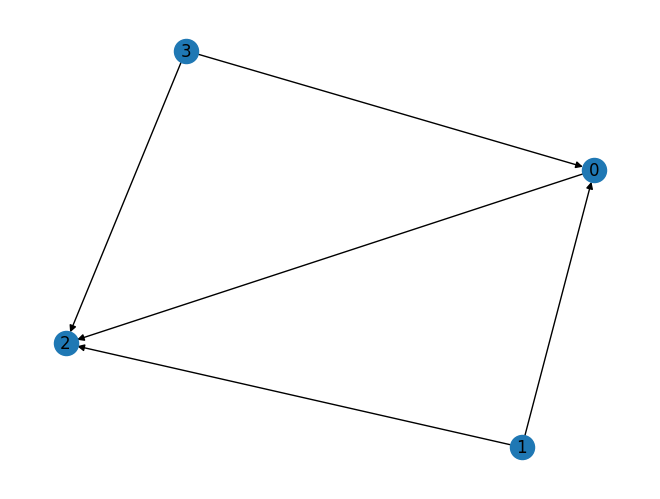

removed (1, 0)
removed (3, 0)
SUMMARY - TRAIN SET (obs0 - used for training)
Method               Train MSE       Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.016340        -0.000973       0.084529        N/A            
Obs PFN              0.074214        0.033563        0.034252        -0.028764      
Int PFN              0.077904        0.027268        0.031733        0.063526       

SUMMARY - OBS2 SET (obs1 - second observational, not trained on)
Method               Obs2 MSE        Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.100724        0.046636        0.066917        N/A            
Obs PFN              0.095334        0.072671        0.033642        0.356660       
Int PFN             

In [8]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 4
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (1, 0), 
            (3, 0),
            (3,2),
            (0,2)
            ]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 3,

    weights = [1.0, 1.0, 1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[0] = LinearMechanism(
        input_dim = 2,

    weights = [5.0, 5.0],
    nonlinearity= lambda x: torch.tanh(x) 
)

mechanisms[3] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)



# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

number_train_samples = 500
number_test_samples = 500
            
# sample the observational data first
scm.sample_exogenous(num_samples=number_train_samples)
scm.sample_endogenous(num_samples=number_train_samples)

obs0_raw = scm.propagate(num_samples=number_train_samples)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}

# now, do interventional sampling
# for interventional sampling, first determine intervention node
intervention_node = 0

scm.sample_exogenous(num_samples=number_test_samples) #sample observational data again. 
scm.sample_endogenous(num_samples=number_test_samples) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=number_test_samples)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)

scm.intervene(node = 0) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist

# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=number_test_samples)
scm.sample_endogenous(num_samples=number_test_samples)

interv1_raw = scm.propagate(num_samples=number_test_samples)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

# Also process the second observational dataset (obs1)
obs1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs1_raw.items()}

X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
X_obs2, T_obs2, Y_obs2, _, _, _ = processor.process_from_splits(obs1, interv1)  # Process second obs dataset

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1)
XT_obs2 = torch.cat([X_obs2, T_obs2], dim=1)

# ============= RANDOM FOREST =============
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and metrics
rf_preds_train = rf.predict(XT_train.numpy())
rf_mse_train = np.mean((Y_train.numpy().ravel() - rf_preds_train)**2)
rf_bias_train = np.mean(rf_preds_train) - np.mean(Y_train.numpy().ravel())
rf_variance_train = np.var(rf_preds_train)

# Test predictions and metrics
rf_preds_test = rf.predict(XT_test.numpy())
rf_mse_test = np.mean((Y_test.numpy().ravel() - rf_preds_test)**2)
rf_bias_test = np.mean(rf_preds_test) - np.mean(Y_test.numpy().ravel())
rf_variance_test = np.var(rf_preds_test)

# Second obs predictions and metrics
rf_preds_obs2 = rf.predict(XT_obs2.numpy())
rf_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - rf_preds_obs2)**2)
rf_bias_obs2 = np.mean(rf_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
rf_variance_obs2 = np.var(rf_preds_obs2)

# ============= OBSERVATIONAL PFN =============
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)
X_obs2_ext = torch.cat([X_obs2, torch.zeros_like(T_obs2)], dim=1)

# Train predictions and metrics
obspfn_preds_train = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = np.mean((Y_train.numpy().ravel() - obspfn_preds_train)**2)
obspfn_bias_train = np.mean(obspfn_preds_train) - np.mean(Y_train.numpy().ravel())
obspfn_variance_train = np.var(obspfn_preds_train)

# Test predictions and metrics
obspfn_preds_test = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
obspfn_mse_test = np.mean((Y_test.numpy().ravel() - obspfn_preds_test)**2)
obspfn_bias_test = np.mean(obspfn_preds_test) - np.mean(Y_test.numpy().ravel())
obspfn_variance_test = np.var(obspfn_preds_test)

# Second obs predictions and metrics
obspfn_preds_obs2 = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
obspfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - obspfn_preds_obs2)**2)
obspfn_bias_obs2 = np.mean(obspfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
obspfn_variance_obs2 = np.var(obspfn_preds_obs2)

# Log-likelihood for train set
obspfn_log_lik_train = obspfn.predict_log_likelihood(
     X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv = Y_train.numpy()
)
obspfn_nll_train = -np.mean(obspfn_log_lik_train)

# Log-likelihood for test set
obspfn_log_lik_test = obspfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
obspfn_nll_test = -np.mean(obspfn_log_lik_test)

# Log-likelihood for second obs set
obspfn_log_lik_obs2 = obspfn.predict_log_likelihood(
    X_obs = X_obs2.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
obspfn_nll_obs2 = -np.mean(obspfn_log_lik_obs2)

# ============= INTERVENTIONAL PFN =============


# Train predictions and metrics
intpfn_preds_train = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"

)
intpfn_mse_train = np.mean((Y_train.numpy().ravel() - intpfn_preds_train)**2)
intpfn_bias_train = np.mean(intpfn_preds_train) - np.mean(Y_train.numpy().ravel())
intpfn_variance_train = np.var(intpfn_preds_train)

# Test predictions and metrics
intpfn_preds_test = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse_test = np.mean((Y_test.numpy().ravel() - intpfn_preds_test)**2)
intpfn_bias_test = np.mean(intpfn_preds_test) - np.mean(Y_test.numpy().ravel())
intpfn_variance_test = np.var(intpfn_preds_test)

# Second obs predictions and metrics
intpfn_preds_obs2 = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
intpfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - intpfn_preds_obs2)**2)
intpfn_bias_obs2 = np.mean(intpfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
intpfn_variance_obs2 = np.var(intpfn_preds_obs2)

# Log-likelihood for train set
intpfn_log_lik_train = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv=  Y_train.numpy()
)
intpfn_nll_train = -np.mean(intpfn_log_lik_train)

# Log-likelihood for test set
intpfn_log_lik_test = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
intpfn_nll_test = -np.mean(intpfn_log_lik_test)

# Log-likelihood for second obs set
intpfn_log_lik_obs2 = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
intpfn_nll_obs2 = -np.mean(intpfn_log_lik_obs2)

# ============= SUMMARY =============
print("="*120)
print("SUMMARY - TRAIN SET (obs0 - used for training)")
print("="*120)
print(f"{'Method':<20} {'Train MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_train:<15.6f} {rf_bias_train:<15.6f} {rf_variance_train:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_train:<15.6f} {obspfn_bias_train:<15.6f} {obspfn_variance_train:<15.6f} {obspfn_nll_train:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train:<15.6f} {intpfn_bias_train:<15.6f} {intpfn_variance_train:<15.6f} {intpfn_nll_train:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - OBS2 SET (obs1 - second observational, not trained on)")
print("="*120)
print(f"{'Method':<20} {'Obs2 MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_obs2:<15.6f} {rf_bias_obs2:<15.6f} {rf_variance_obs2:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_obs2:<15.6f} {obspfn_bias_obs2:<15.6f} {obspfn_variance_obs2:<15.6f} {obspfn_nll_obs2:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_obs2:<15.6f} {intpfn_bias_obs2:<15.6f} {intpfn_variance_obs2:<15.6f} {intpfn_nll_obs2:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - TEST SET (interventional)")
print("="*120)
print(f"{'Method':<20} {'Test MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_test:<15.6f} {rf_bias_test:<15.6f} {rf_variance_test:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_test:<15.6f} {obspfn_bias_test:<15.6f} {obspfn_variance_test:<15.6f} {obspfn_nll_test:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_test:<15.6f} {intpfn_bias_test:<15.6f} {intpfn_variance_test:<15.6f} {intpfn_nll_test:<15.6f}")
print("="*120)


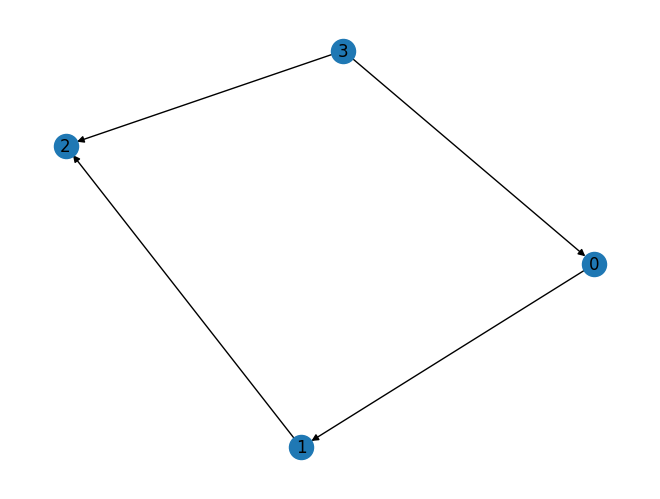

removed (3, 0)
SUMMARY - TRAIN SET (obs0 - used for training)
Method               Train MSE       Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.001411        -0.000645       0.468198        N/A            
Obs PFN              0.008211        0.003184        0.418013        -1.056775      
Int PFN              0.007921        0.005465        0.425544        -1.038014      

SUMMARY - OBS2 SET (obs1 - second observational, not trained on)
Method               Obs2 MSE        Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.015225        0.081922        0.464632        N/A            
Obs PFN              0.016046        0.085816        0.419999        -0.374390      
Int PFN              0.016763      

In [19]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 4
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
            (3, 0),
            (3,2),
            #(0,2)
            ]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[0] = LinearMechanism(
        input_dim = 1,

    weights = [3.0],
    nonlinearity= lambda x: torch.tanh(x) 
)

mechanisms[3] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)



# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1.0)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 0.1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

number_train_samples = 500
number_test_samples = 500
            
# sample the observational data first
scm.sample_exogenous(num_samples=number_train_samples)
scm.sample_endogenous(num_samples=number_train_samples)

obs0_raw = scm.propagate(num_samples=number_train_samples)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}

# now, do interventional sampling
# for interventional sampling, first determine intervention node
intervention_node = 0

scm.sample_exogenous(num_samples=number_test_samples) #sample observational data again. 
scm.sample_endogenous(num_samples=number_test_samples) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=number_test_samples)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)

scm.intervene(node = 0) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist

# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=number_test_samples)
scm.sample_endogenous(num_samples=number_test_samples)

interv1_raw = scm.propagate(num_samples=number_test_samples)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

# Also process the second observational dataset (obs1)
obs1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs1_raw.items()}

X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
X_obs2, T_obs2, Y_obs2, _, _, _ = processor.process_from_splits(obs1, interv1)  # Process second obs dataset

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1)
XT_obs2 = torch.cat([X_obs2, T_obs2], dim=1)

# ============= RANDOM FOREST =============
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and metrics
rf_preds_train = rf.predict(XT_train.numpy())
rf_mse_train = np.mean((Y_train.numpy().ravel() - rf_preds_train)**2)
rf_bias_train = np.mean(rf_preds_train) - np.mean(Y_train.numpy().ravel())
rf_variance_train = np.var(rf_preds_train)

# Test predictions and metrics
rf_preds_test = rf.predict(XT_test.numpy())
rf_mse_test = np.mean((Y_test.numpy().ravel() - rf_preds_test)**2)
rf_bias_test = np.mean(rf_preds_test) - np.mean(Y_test.numpy().ravel())
rf_variance_test = np.var(rf_preds_test)

# Second obs predictions and metrics
rf_preds_obs2 = rf.predict(XT_obs2.numpy())
rf_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - rf_preds_obs2)**2)
rf_bias_obs2 = np.mean(rf_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
rf_variance_obs2 = np.var(rf_preds_obs2)

# ============= OBSERVATIONAL PFN =============
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)
X_obs2_ext = torch.cat([X_obs2, torch.zeros_like(T_obs2)], dim=1)

# Train predictions and metrics
obspfn_preds_train = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = np.mean((Y_train.numpy().ravel() - obspfn_preds_train)**2)
obspfn_bias_train = np.mean(obspfn_preds_train) - np.mean(Y_train.numpy().ravel())
obspfn_variance_train = np.var(obspfn_preds_train)

# Test predictions and metrics
obspfn_preds_test = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
obspfn_mse_test = np.mean((Y_test.numpy().ravel() - obspfn_preds_test)**2)
obspfn_bias_test = np.mean(obspfn_preds_test) - np.mean(Y_test.numpy().ravel())
obspfn_variance_test = np.var(obspfn_preds_test)

# Second obs predictions and metrics
obspfn_preds_obs2 = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
obspfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - obspfn_preds_obs2)**2)
obspfn_bias_obs2 = np.mean(obspfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
obspfn_variance_obs2 = np.var(obspfn_preds_obs2)

# Log-likelihood for train set
obspfn_log_lik_train = obspfn.predict_log_likelihood(
     X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv = Y_train.numpy()
)
obspfn_nll_train = -np.mean(obspfn_log_lik_train)

# Log-likelihood for test set
obspfn_log_lik_test = obspfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
obspfn_nll_test = -np.mean(obspfn_log_lik_test)

# Log-likelihood for second obs set
obspfn_log_lik_obs2 = obspfn.predict_log_likelihood(
    X_obs = X_obs2.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
obspfn_nll_obs2 = -np.mean(obspfn_log_lik_obs2)

# ============= INTERVENTIONAL PFN =============


# Train predictions and metrics
intpfn_preds_train = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"

)
intpfn_mse_train = np.mean((Y_train.numpy().ravel() - intpfn_preds_train)**2)
intpfn_bias_train = np.mean(intpfn_preds_train) - np.mean(Y_train.numpy().ravel())
intpfn_variance_train = np.var(intpfn_preds_train)

# Test predictions and metrics
intpfn_preds_test = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse_test = np.mean((Y_test.numpy().ravel() - intpfn_preds_test)**2)
intpfn_bias_test = np.mean(intpfn_preds_test) - np.mean(Y_test.numpy().ravel())
intpfn_variance_test = np.var(intpfn_preds_test)

# Second obs predictions and metrics
intpfn_preds_obs2 = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
intpfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - intpfn_preds_obs2)**2)
intpfn_bias_obs2 = np.mean(intpfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
intpfn_variance_obs2 = np.var(intpfn_preds_obs2)

# Log-likelihood for train set
intpfn_log_lik_train = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv=  Y_train.numpy()
)
intpfn_nll_train = -np.mean(intpfn_log_lik_train)

# Log-likelihood for test set
intpfn_log_lik_test = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
intpfn_nll_test = -np.mean(intpfn_log_lik_test)

# Log-likelihood for second obs set
intpfn_log_lik_obs2 = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
intpfn_nll_obs2 = -np.mean(intpfn_log_lik_obs2)

# ============= SUMMARY =============
print("="*120)
print("SUMMARY - TRAIN SET (obs0 - used for training)")
print("="*120)
print(f"{'Method':<20} {'Train MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_train:<15.6f} {rf_bias_train:<15.6f} {rf_variance_train:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_train:<15.6f} {obspfn_bias_train:<15.6f} {obspfn_variance_train:<15.6f} {obspfn_nll_train:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train:<15.6f} {intpfn_bias_train:<15.6f} {intpfn_variance_train:<15.6f} {intpfn_nll_train:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - OBS2 SET (obs1 - second observational, not trained on)")
print("="*120)
print(f"{'Method':<20} {'Obs2 MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_obs2:<15.6f} {rf_bias_obs2:<15.6f} {rf_variance_obs2:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_obs2:<15.6f} {obspfn_bias_obs2:<15.6f} {obspfn_variance_obs2:<15.6f} {obspfn_nll_obs2:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_obs2:<15.6f} {intpfn_bias_obs2:<15.6f} {intpfn_variance_obs2:<15.6f} {intpfn_nll_obs2:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - TEST SET (interventional)")
print("="*120)
print(f"{'Method':<20} {'Test MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_test:<15.6f} {rf_bias_test:<15.6f} {rf_variance_test:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_test:<15.6f} {obspfn_bias_test:<15.6f} {obspfn_variance_test:<15.6f} {obspfn_nll_test:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_test:<15.6f} {intpfn_bias_test:<15.6f} {intpfn_variance_test:<15.6f} {intpfn_nll_test:<15.6f}")
print("="*120)


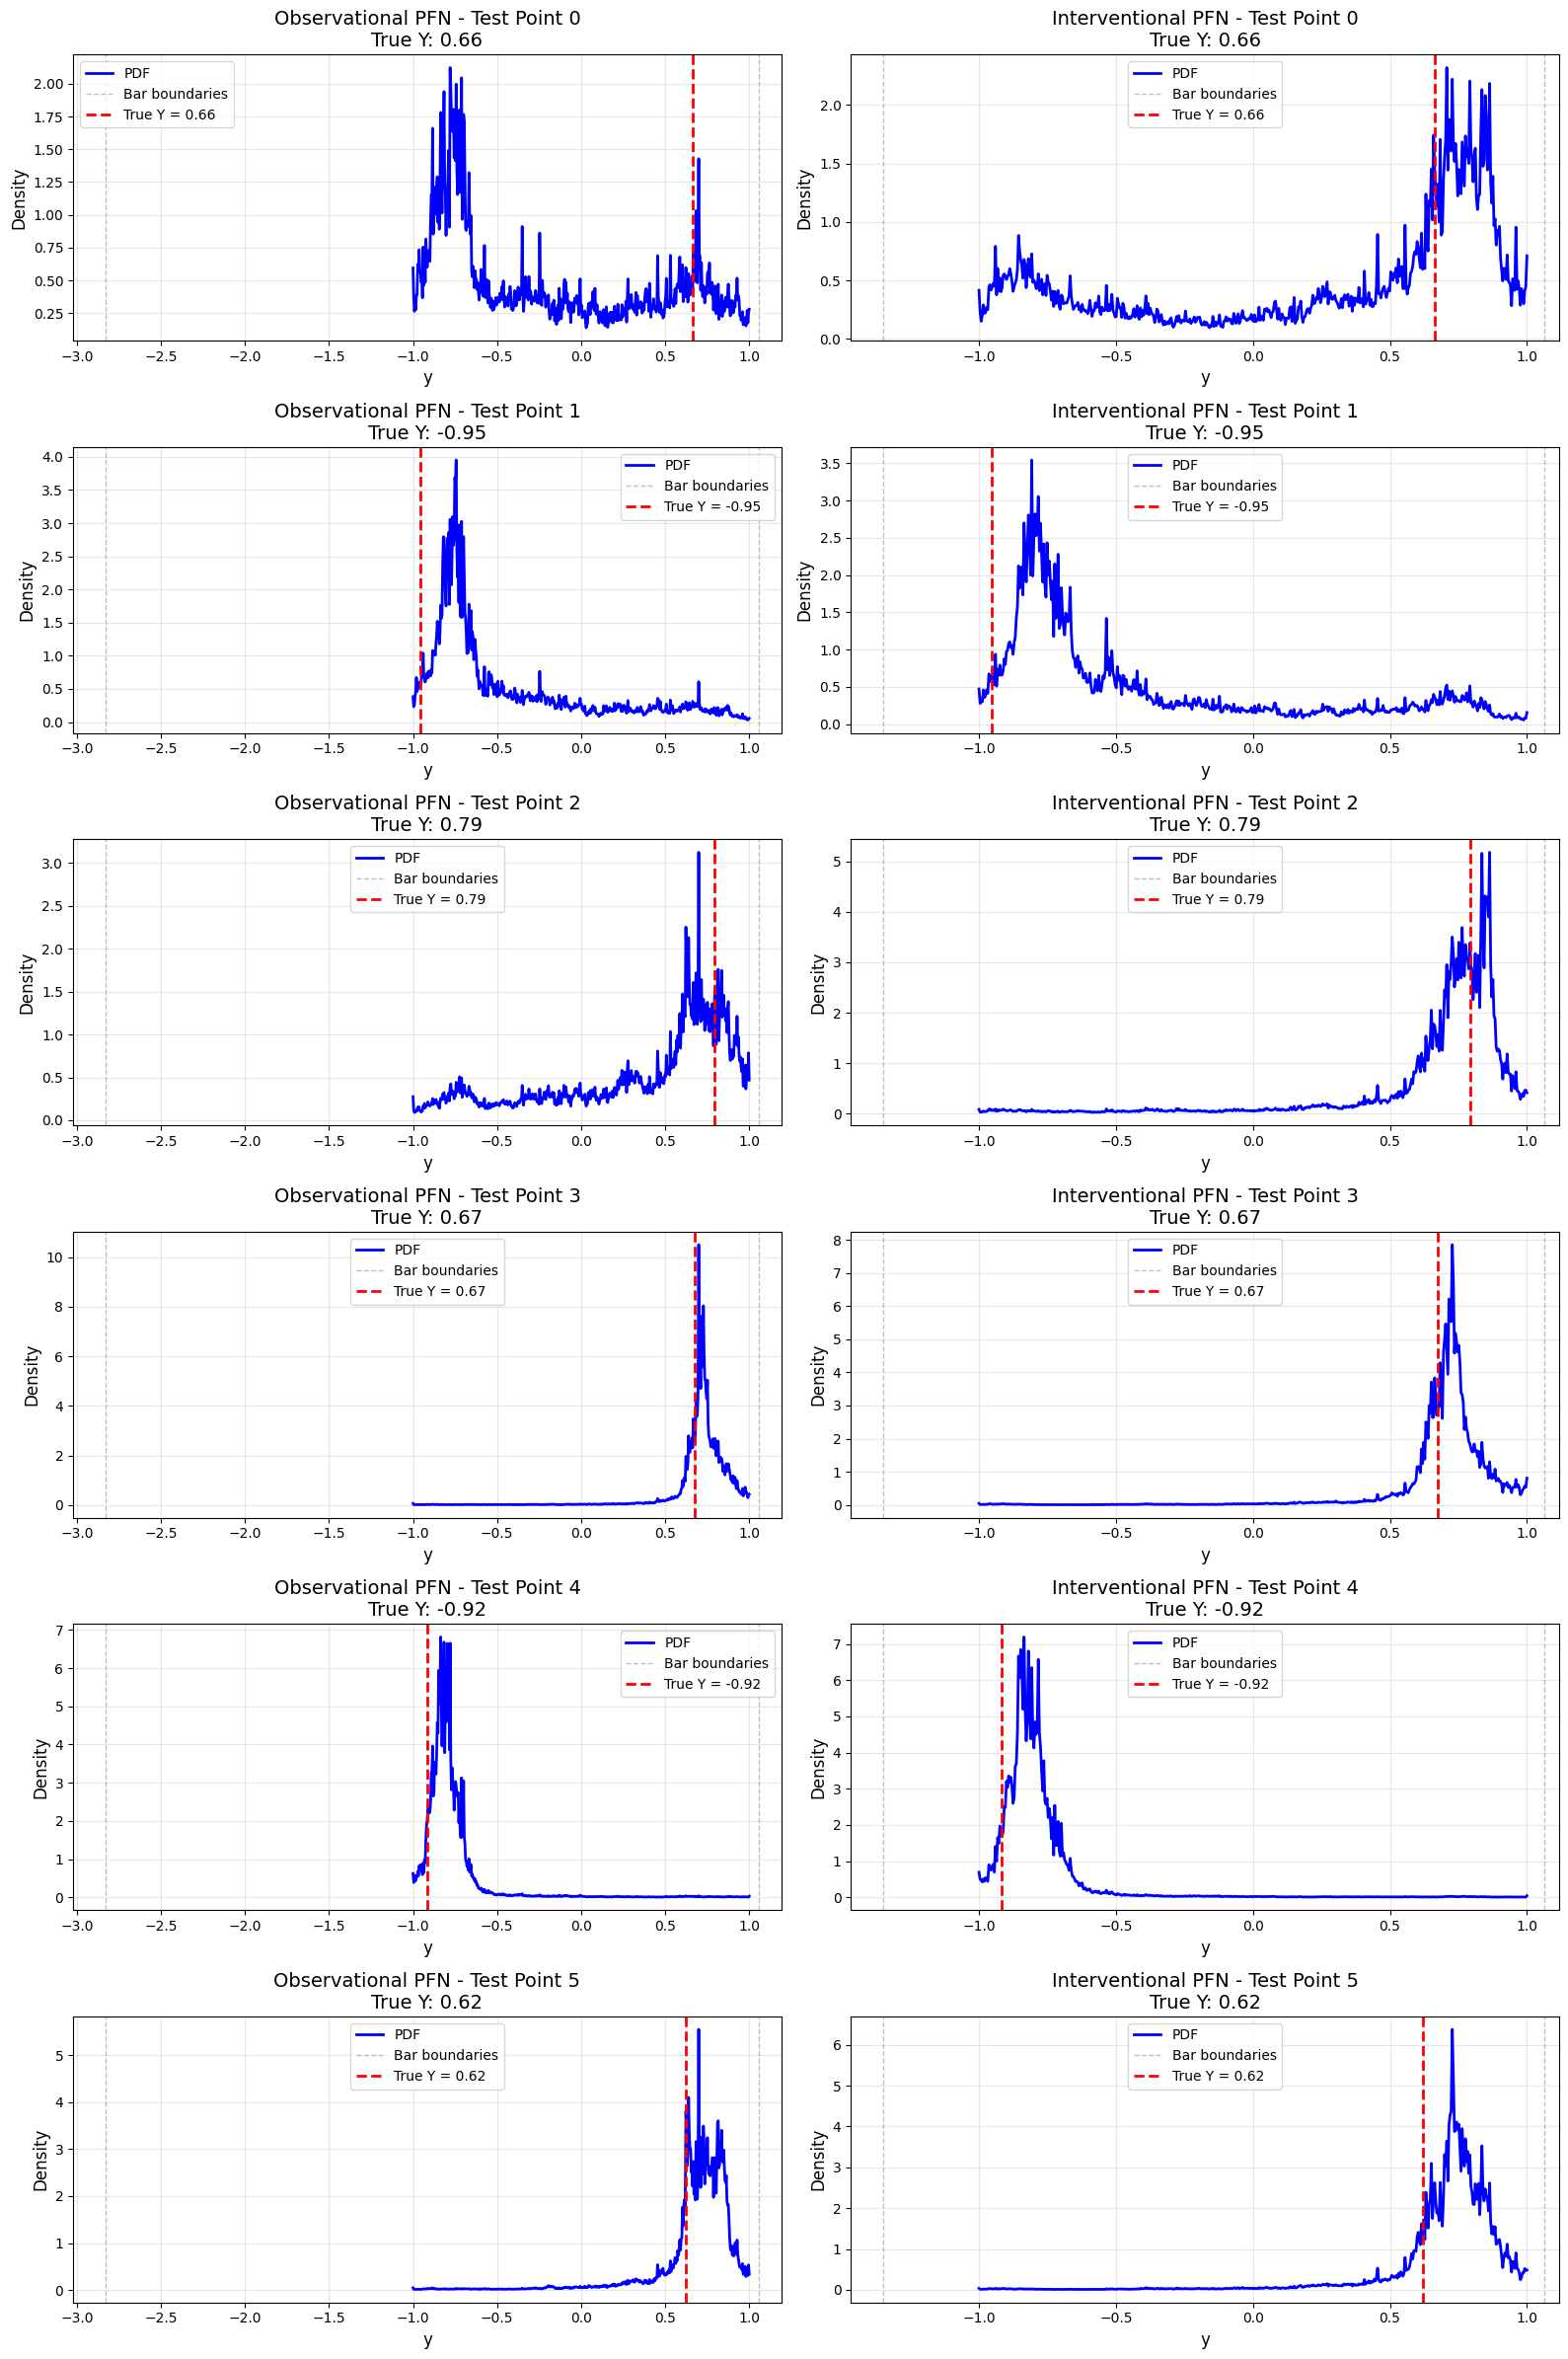


Distribution visualization complete!
Red dashed line shows the true observed value.


In [16]:
import matplotlib.pyplot as plt

# Select a few test points to visualize
test_indices = [0, 1, 2,3,4,5,]  # First three test points

# Create subplots for comparison
fig, axes = plt.subplots(len(test_indices), 2, figsize=(16,4 *len(test_indices)))
if len(test_indices) == 1:
    axes = axes.reshape(1, -1)

for i, test_idx in enumerate(test_indices):
    # Get raw predictions for this test point
    # For observational PFN
    obs_pred = obspfn.get_raw_predictions(
        X_obs = X_train.numpy(),
        T_obs = T_train.numpy(),
        Y_obs = Y_train.squeeze().numpy(),
        X_intv = X_test[[test_idx]].numpy(),
        T_intv = T_test[[test_idx]].numpy()
    )

    # For interventional PFN
    int_pred = intpfn.get_raw_predictions(
        X_obs = X_train.numpy(),
        T_obs = T_train.numpy(),
        Y_obs = Y_train.squeeze().numpy(),
        X_intv = X_test[[test_idx]].numpy(),
        T_intv = T_test[[test_idx]].numpy()
    )
    
    # Plot observational PFN distribution
    obspfn.bar_distribution.plot(
        obs_pred, idx=0, ax=axes[i, 0],
        title=f"Observational PFN - Test Point {test_idx}\nTrue Y: {Y_test[test_idx].item():.2f}",
        y_range = (-1,1)
    )
    axes[i, 0].axvline(Y_test[test_idx].item(), color='red', linestyle='--', 
                       linewidth=2, label=f'True Y = {Y_test[test_idx].item():.2f}')
    axes[i, 0].legend()
    
    # Plot interventional PFN distribution
    intpfn.bar_distribution.plot(
        int_pred, idx=0, ax=axes[i, 1],
        title=f"Interventional PFN - Test Point {test_idx}\nTrue Y: {Y_test[test_idx].item():.2f}",
         y_range =(-1,1)
    )
    axes[i, 1].axvline(Y_test[test_idx].item(), color='red', linestyle='--',
                       linewidth=2, label=f'True Y = {Y_test[test_idx].item():.2f}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

print("\nDistribution visualization complete!")
print("Red dashed line shows the true observed value.")

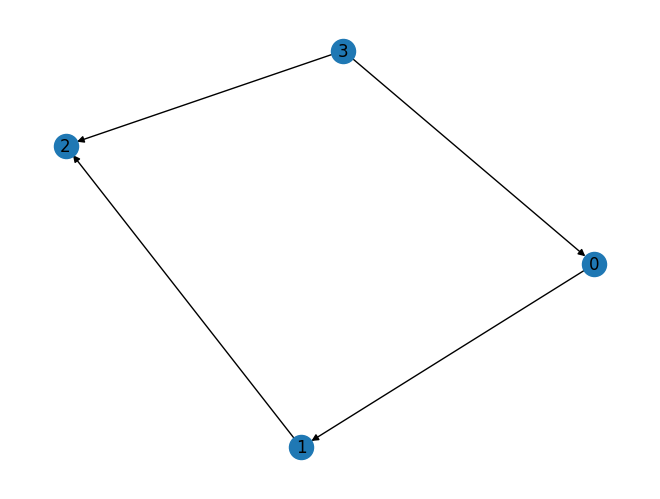

SUMMARY - TRAIN SET (obs0 - used for training)
Method               Train MSE       Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.003377        0.003326        0.608767        N/A            
Obs PFN              0.009488        0.000029        0.535701        -1.109848      
Int PFN              0.010282        0.000162        0.541873        -1.075069      

SUMMARY - OBS2 SET (obs1 - second observational, not trained on)
Method               Obs2 MSE        Bias            Variance        NLL            
------------------------------------------------------------------------------------------------------------------------
Random Forest        0.012692        -0.022024       0.615036        N/A            
Obs PFN              0.010445        -0.028087       0.539500        -0.778969      
Int PFN              0.009005        -0.028077    

In [24]:
# Unobserved confounder

from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np

NUM_NODES = 4
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
            (3, 0),
            (3,2),
            #(0,2)
            ]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
    input_dim=2,
    weights=[5.0, 10.0],  # make U -> Y big
    nonlinearity=lambda x: torch.tanh(x),
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: torch.tanh(x)
)

mechanisms[0] = LinearMechanism(
    input_dim=1,
    weights=[10.0],   # was 3.0 : stronger U -> T
    nonlinearity=lambda x: torch.tanh(x),
)



# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1.0)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 0.1)


endo_noise[2] = NormalDistribution(mean=0, std=0.1)  # was 0.1
endo_noise[0] = NormalDistribution(mean=0, std=0.1)
endo_noise[1] = NormalDistribution(mean=0, std=0.5)  # make X noisy (bigger than others)

scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

number_train_samples = 500
number_test_samples = 500
            
# sample the observational data first
scm.sample_exogenous(num_samples=number_train_samples)
scm.sample_endogenous(num_samples=number_train_samples)

obs0_raw = scm.propagate(num_samples=number_train_samples)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}

# now, do interventional sampling
# for interventional sampling, first determine intervention node
intervention_node = 0

scm.sample_exogenous(num_samples=number_test_samples) #sample observational data again. 
scm.sample_endogenous(num_samples=number_test_samples) #sample observational data again. 

obs1_raw = scm.propagate(num_samples=number_test_samples)  # fresh observational batch (test-size)

# Collect observational samples for the chosen intervention node (marginal)
intervention_samples = obs1_raw[intervention_node]

# Resampling distribution over observational marginal (without replacement)
interventional_dist = ResamplingDist(intervention_samples)

scm.intervene(node = 0) # intervene on the chosen node

# Replace the noise distribution for the intervened node with its observational marginal
if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist
if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist

# Sample new noise for interventional scenario
scm.sample_exogenous(num_samples=number_test_samples)
scm.sample_endogenous(num_samples=number_test_samples)

interv1_raw = scm.propagate(num_samples=number_test_samples)  # interventional data (post-intervention)
# Reshape from (N,) to (N,1) for BasicProcessing compatibility
interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}

# Also process the second observational dataset (obs1)
obs1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs1_raw.items()}

X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
X_obs2, T_obs2, Y_obs2, _, _, _ = processor.process_from_splits(obs1, interv1)  # Process second obs dataset

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1)
XT_obs2 = torch.cat([X_obs2, T_obs2], dim=1)

# ============= RANDOM FOREST =============
rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())

# Train predictions and metrics
rf_preds_train = rf.predict(XT_train.numpy())
rf_mse_train = np.mean((Y_train.numpy().ravel() - rf_preds_train)**2)
rf_bias_train = np.mean(rf_preds_train) - np.mean(Y_train.numpy().ravel())
rf_variance_train = np.var(rf_preds_train)

# Test predictions and metrics
rf_preds_test = rf.predict(XT_test.numpy())
rf_mse_test = np.mean((Y_test.numpy().ravel() - rf_preds_test)**2)
rf_bias_test = np.mean(rf_preds_test) - np.mean(Y_test.numpy().ravel())
rf_variance_test = np.var(rf_preds_test)

# Second obs predictions and metrics
rf_preds_obs2 = rf.predict(XT_obs2.numpy())
rf_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - rf_preds_obs2)**2)
rf_bias_obs2 = np.mean(rf_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
rf_variance_obs2 = np.var(rf_preds_obs2)

# ============= OBSERVATIONAL PFN =============
X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)
X_obs2_ext = torch.cat([X_obs2, torch.zeros_like(T_obs2)], dim=1)

# Train predictions and metrics
obspfn_preds_train = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"
)
obspfn_mse_train = np.mean((Y_train.numpy().ravel() - obspfn_preds_train)**2)
obspfn_bias_train = np.mean(obspfn_preds_train) - np.mean(Y_train.numpy().ravel())
obspfn_variance_train = np.var(obspfn_preds_train)

# Test predictions and metrics
obspfn_preds_test = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
obspfn_mse_test = np.mean((Y_test.numpy().ravel() - obspfn_preds_test)**2)
obspfn_bias_test = np.mean(obspfn_preds_test) - np.mean(Y_test.numpy().ravel())
obspfn_variance_test = np.var(obspfn_preds_test)

# Second obs predictions and metrics
obspfn_preds_obs2 = obspfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
obspfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - obspfn_preds_obs2)**2)
obspfn_bias_obs2 = np.mean(obspfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
obspfn_variance_obs2 = np.var(obspfn_preds_obs2)

# Log-likelihood for train set
obspfn_log_lik_train = obspfn.predict_log_likelihood(
     X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv = Y_train.numpy()
)
obspfn_nll_train = -np.mean(obspfn_log_lik_train)

# Log-likelihood for test set
obspfn_log_lik_test = obspfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
obspfn_nll_test = -np.mean(obspfn_log_lik_test)

# Log-likelihood for second obs set
obspfn_log_lik_obs2 = obspfn.predict_log_likelihood(
    X_obs = X_obs2.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
obspfn_nll_obs2 = -np.mean(obspfn_log_lik_obs2)

# ============= INTERVENTIONAL PFN =============


# Train predictions and metrics
intpfn_preds_train = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    prediction_type="mean"

)
intpfn_mse_train = np.mean((Y_train.numpy().ravel() - intpfn_preds_train)**2)
intpfn_bias_train = np.mean(intpfn_preds_train) - np.mean(Y_train.numpy().ravel())
intpfn_variance_train = np.var(intpfn_preds_train)

# Test predictions and metrics
intpfn_preds_test = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    prediction_type="mean"
)
intpfn_mse_test = np.mean((Y_test.numpy().ravel() - intpfn_preds_test)**2)
intpfn_bias_test = np.mean(intpfn_preds_test) - np.mean(Y_test.numpy().ravel())
intpfn_variance_test = np.var(intpfn_preds_test)

# Second obs predictions and metrics
intpfn_preds_obs2 = intpfn.predict(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    prediction_type="mean"
)
intpfn_mse_obs2 = np.mean((Y_obs2.numpy().ravel() - intpfn_preds_obs2)**2)
intpfn_bias_obs2 = np.mean(intpfn_preds_obs2) - np.mean(Y_obs2.numpy().ravel())
intpfn_variance_obs2 = np.var(intpfn_preds_obs2)

# Log-likelihood for train set
intpfn_log_lik_train = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_train.numpy(),
    T_intv= T_train.numpy(),
    Y_intv=  Y_train.numpy()
)
intpfn_nll_train = -np.mean(intpfn_log_lik_train)

# Log-likelihood for test set
intpfn_log_lik_test = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_test.numpy(),
    T_intv= T_test.numpy(),
    Y_intv = Y_test.numpy()
)
intpfn_nll_test = -np.mean(intpfn_log_lik_test)

# Log-likelihood for second obs set
intpfn_log_lik_obs2 = intpfn.predict_log_likelihood(
    X_obs = X_train.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_obs2.numpy(),
    T_intv= T_obs2.numpy(),
    Y_intv = Y_obs2.numpy()
)
intpfn_nll_obs2 = -np.mean(intpfn_log_lik_obs2)

# ============= SUMMARY =============
print("="*120)
print("SUMMARY - TRAIN SET (obs0 - used for training)")
print("="*120)
print(f"{'Method':<20} {'Train MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_train:<15.6f} {rf_bias_train:<15.6f} {rf_variance_train:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_train:<15.6f} {obspfn_bias_train:<15.6f} {obspfn_variance_train:<15.6f} {obspfn_nll_train:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_train:<15.6f} {intpfn_bias_train:<15.6f} {intpfn_variance_train:<15.6f} {intpfn_nll_train:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - OBS2 SET (obs1 - second observational, not trained on)")
print("="*120)
print(f"{'Method':<20} {'Obs2 MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_obs2:<15.6f} {rf_bias_obs2:<15.6f} {rf_variance_obs2:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_obs2:<15.6f} {obspfn_bias_obs2:<15.6f} {obspfn_variance_obs2:<15.6f} {obspfn_nll_obs2:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_obs2:<15.6f} {intpfn_bias_obs2:<15.6f} {intpfn_variance_obs2:<15.6f} {intpfn_nll_obs2:<15.6f}")
print("="*120)

print("\n" + "="*120)
print("SUMMARY - TEST SET (interventional)")
print("="*120)
print(f"{'Method':<20} {'Test MSE':<15} {'Bias':<15} {'Variance':<15} {'NLL':<15}")
print("-"*120)
print(f"{'Random Forest':<20} {rf_mse_test:<15.6f} {rf_bias_test:<15.6f} {rf_variance_test:<15.6f} {'N/A':<15}")
print(f"{'Obs PFN':<20} {obspfn_mse_test:<15.6f} {obspfn_bias_test:<15.6f} {obspfn_variance_test:<15.6f} {obspfn_nll_test:<15.6f}")
print(f"{'Int PFN':<20} {intpfn_mse_test:<15.6f} {intpfn_bias_test:<15.6f} {intpfn_variance_test:<15.6f} {intpfn_nll_test:<15.6f}")
print("="*120)


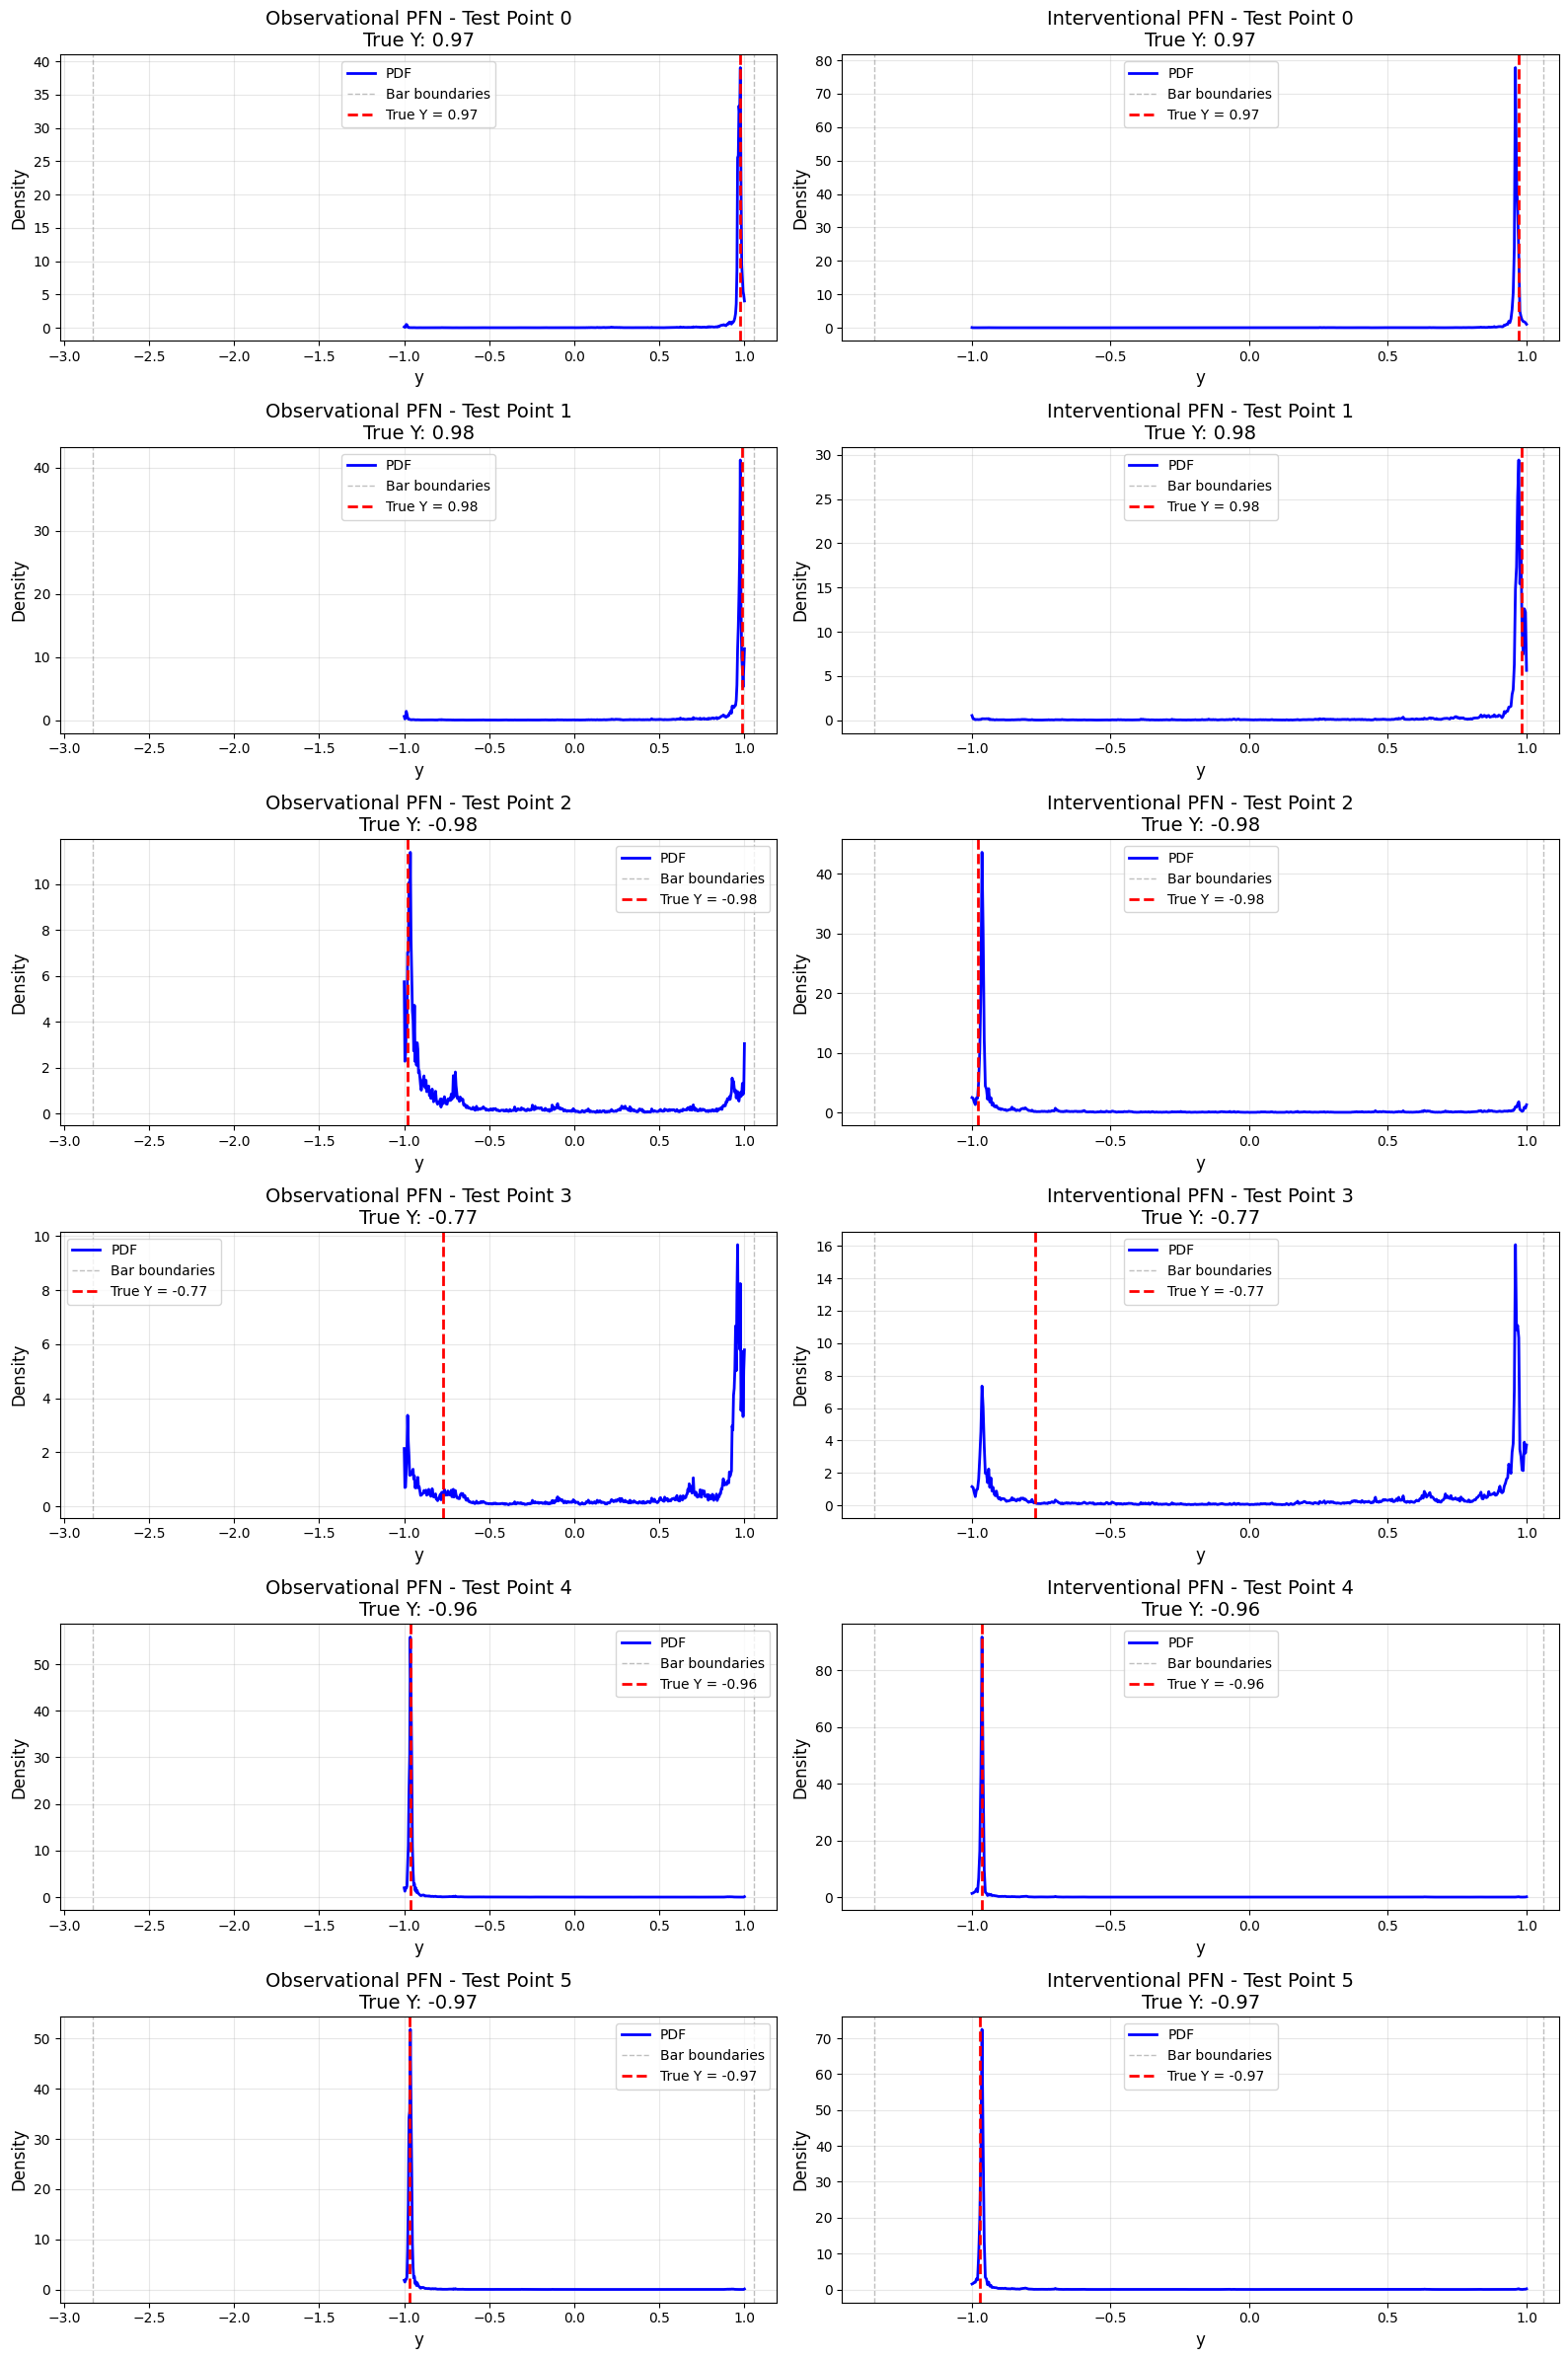


Distribution visualization complete!
Red dashed line shows the true observed value.


In [23]:
import matplotlib.pyplot as plt

# Select a few test points to visualize
test_indices = [0, 1, 2,3,4,5,]  # First three test points

# Create subplots for comparison
fig, axes = plt.subplots(len(test_indices), 2, figsize=(16,4 *len(test_indices)))
if len(test_indices) == 1:
    axes = axes.reshape(1, -1)

for i, test_idx in enumerate(test_indices):
    # Get raw predictions for this test point
    # For observational PFN
    obs_pred = obspfn.get_raw_predictions(
        X_obs = X_train.numpy(),
        T_obs = T_train.numpy(),
        Y_obs = Y_train.squeeze().numpy(),
        X_intv = X_test[[test_idx]].numpy(),
        T_intv = T_test[[test_idx]].numpy()
    )

    # For interventional PFN
    int_pred = intpfn.get_raw_predictions(
        X_obs = X_train.numpy(),
        T_obs = T_train.numpy(),
        Y_obs = Y_train.squeeze().numpy(),
        X_intv = X_test[[test_idx]].numpy(),
        T_intv = T_test[[test_idx]].numpy()
    )
    
    # Plot observational PFN distribution
    obspfn.bar_distribution.plot(
        obs_pred, idx=0, ax=axes[i, 0],
        title=f"Observational PFN - Test Point {test_idx}\nTrue Y: {Y_test[test_idx].item():.2f}",
        y_range = (-1,1)
    )
    axes[i, 0].axvline(Y_test[test_idx].item(), color='red', linestyle='--', 
                       linewidth=2, label=f'True Y = {Y_test[test_idx].item():.2f}')
    axes[i, 0].legend()
    
    # Plot interventional PFN distribution
    intpfn.bar_distribution.plot(
        int_pred, idx=0, ax=axes[i, 1],
        title=f"Interventional PFN - Test Point {test_idx}\nTrue Y: {Y_test[test_idx].item():.2f}",
         y_range =(-1,1)
    )
    axes[i, 1].axvline(Y_test[test_idx].item(), color='red', linestyle='--',
                       linewidth=2, label=f'True Y = {Y_test[test_idx].item():.2f}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

print("\nDistribution visualization complete!")
print("Red dashed line shows the true observed value.")